# Multi-Seed Random Forest Model Comparison
This notebook runs the Random Forest Improved model with multiple different seeds and compares performance across all seeds, including average metrics.

**Features:**
- Tests model with 10 different random seeds
- Calculates average performance metrics
- Identifies best and worst performing seeds
- Generates comprehensive comparison visualizations
- Saves results to JSON file

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import json
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

print("✓ All packages imported successfully!")

## Configuration
Set the random seeds to test. You can modify this list to test different seeds.

In [ ]:
# Define seeds to test - MODIFY THIS LIST AS NEEDED
SEEDS = [42, 50, 100, 123, 200, 250, 275, 350, 400, 500]

# Model parameters (using good defaults for speed)
MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 20,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}

print(f"Testing {len(SEEDS)} seeds: {SEEDS}")
print(f"Model parameters: {MODEL_PARAMS}")

## Load and Prepare Data

In [ ]:
# Load data
df = pd.read_excel("Random Forest Data.xlsx", header=1, usecols="B:L")
stream = df[df["Rain or Stream"].str.lower().eq("stream")].copy()

# Feature engineering
stream['Month'] = stream['Date'].dt.month
stream['Day_of_Year'] = stream['Date'].dt.dayofyear
stream['Year'] = stream['Date'].dt.year
stream["DOY_sin"] = np.sin(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream["DOY_cos"] = np.cos(2 * np.pi * stream['Day_of_Year'] / 365.25)
stream['Temp_Discharge_Interaction'] = stream['Temperature '] * stream['Discharge (m3/s)']
stream['Rain'] = stream['Precipitation (mm)']
stream['Elevation'] = stream['Elevation (ft)']

# Define features
feature_col = [
    "Site ID", 
    "Temperature ", 
    "Discharge (m3/s)",
    "DOY_sin",
    "DOY_cos",
    "Temp_Discharge_Interaction",
    "Rain",
    "Elevation"
]

X = stream[feature_col]
y = stream["δ18O"]

print(f"✓ Data loaded: {len(X)} samples")
print(f"✓ Features: {feature_col}")

## Run Model with Multiple Seeds
This will take a few minutes depending on the number of seeds.

In [23]:
from sklearn.model_selection import TimeSeriesSplit, LeaveOneOut
import time

results = []
models = {}

print("="*70)
print("RUNNING MULTI-SEED EXPERIMENT")
print("="*70)

for i, seed in enumerate(SEEDS, 1):
    print(f"\n[{i}/{len(SEEDS)}] Testing seed {seed}...")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, shuffle=True
    )
    
    # Baseline model
    baseline_rf = RandomForestRegressor(random_state=seed)
    baseline_rf.fit(X_train, y_train)
    y_pred_baseline = baseline_rf.predict(X_test)
    baseline_r2 = r2_score(y_test, y_pred_baseline)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
    baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
    
    # Optimized model
    optimized_rf = RandomForestRegressor(**MODEL_PARAMS, random_state=seed)
    optimized_rf.fit(X_train, y_train)
    y_pred_optimized = optimized_rf.predict(X_test)
    
    # Test set metrics
    optimized_r2 = r2_score(y_test, y_pred_optimized)
    optimized_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
    optimized_mae = mean_absolute_error(y_test, y_pred_optimized)
    
    # K-Fold Cross-validation (Time Series Split)
    print(f"  Running K-Fold CV...")
    tscv = TimeSeriesSplit(n_splits=3)
    kfold_scores = cross_val_score(optimized_rf, X, y, cv=tscv, scoring='r2')
    kfold_mean = kfold_scores.mean()
    kfold_std = kfold_scores.std()
    
    # Get K-Fold predictions for visualization
    splits = list(tscv.split(X))
    y_pred_kfold = np.full(len(y), np.nan)
    
    for train_idx, test_idx in splits:
        model_kfold = RandomForestRegressor(**MODEL_PARAMS, random_state=seed)
        model_kfold.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred_kfold[test_idx] = model_kfold.predict(X.iloc[test_idx])
    
    # Fill missing predictions (first block)
    missing_mask = np.isnan(y_pred_kfold)
    if missing_mask.any():
        first_train_idx = splits[0][0]
        model_init = RandomForestRegressor(**MODEL_PARAMS, random_state=seed)
        model_init.fit(X.iloc[first_train_idx], y.iloc[first_train_idx])
        y_pred_kfold[missing_mask] = model_init.predict(X.iloc[missing_mask])
    
    kfold_r2_overall = r2_score(y, y_pred_kfold)
    kfold_rmse_overall = np.sqrt(mean_squared_error(y, y_pred_kfold))
    kfold_mae_overall = mean_absolute_error(y, y_pred_kfold)
    
    # Leave-One-Out Cross-Validation (LOOCV)
    print(f"  Running LOOCV (this may take a minute)...")
    loo = LeaveOneOut()
    y_true_loocv = []
    y_pred_loocv = []
    
    start_time = time.time()
    for train_index, test_index in loo.split(X):
        X_train_loo, X_test_loo = X.iloc[train_index], X.iloc[test_index]
        y_train_loo, y_test_loo = y.iloc[train_index], y.iloc[test_index]
        
        model_loo = RandomForestRegressor(**MODEL_PARAMS, random_state=seed)
        model_loo.fit(X_train_loo, y_train_loo)
        y_pred = model_loo.predict(X_test_loo)
        
        y_true_loocv.append(y_test_loo.values[0])
        y_pred_loocv.append(y_pred[0])
    
    elapsed_time = time.time() - start_time
    
    y_true_loocv = np.array(y_true_loocv)
    y_pred_loocv = np.array(y_pred_loocv)
    
    loocv_r2 = r2_score(y_true_loocv, y_pred_loocv)
    loocv_rmse = np.sqrt(mean_squared_error(y_true_loocv, y_pred_loocv))
    loocv_mae = mean_absolute_error(y_true_loocv, y_pred_loocv)
    
    print(f"  Test Set:  R²={optimized_r2:.4f}, RMSE={optimized_rmse:.4f}")
    print(f"  K-Fold CV: R²={kfold_r2_overall:.4f}, RMSE={kfold_rmse_overall:.4f}")
    print(f"  LOOCV:     R²={loocv_r2:.4f}, RMSE={loocv_rmse:.4f} (took {elapsed_time:.1f}s)")
    
    # Store results
    results.append({
        'seed': seed,
        'baseline_r2': baseline_r2,
        'baseline_rmse': baseline_rmse,
        'baseline_mae': baseline_mae,
        'optimized_r2': optimized_r2,
        'optimized_rmse': optimized_rmse,
        'optimized_mae': optimized_mae,
        'kfold_r2_mean': kfold_mean,
        'kfold_r2_std': kfold_std,
        'kfold_r2_overall': kfold_r2_overall,
        'kfold_rmse_overall': kfold_rmse_overall,
        'kfold_mae_overall': kfold_mae_overall,
        'loocv_r2': loocv_r2,
        'loocv_rmse': loocv_rmse,
        'loocv_mae': loocv_mae,
        'y_test': y_test.values,
        'y_pred': y_pred_optimized,
        'y_pred_kfold': y_pred_kfold,
        'y_true_loocv': y_true_loocv,
        'y_pred_loocv': y_pred_loocv,
        'feature_importance': dict(zip(X.columns, optimized_rf.feature_importances_))
    })
    
    models[seed] = optimized_rf

print("\n" + "="*70)
print("✓ ALL SEEDS COMPLETED!")
print("="*70)

  Running LOOCV (this may take a minute)...
  Test Set:  R²=0.7208, RMSE=0.6617
  K-Fold CV: R²=0.5442, RMSE=0.7178
  LOOCV:     R²=0.6563, RMSE=0.6233 (took 23.1s)

[2/10] Testing seed 50...
  Running K-Fold CV...
  Running LOOCV (this may take a minute)...
  Test Set:  R²=0.5021, RMSE=0.4272
  K-Fold CV: R²=0.5397, RMSE=0.7214
  LOOCV:     R²=0.6456, RMSE=0.6330 (took 24.0s)

[3/10] Testing seed 100...
  Running K-Fold CV...
  Running LOOCV (this may take a minute)...
  Test Set:  R²=0.3014, RMSE=0.5790
  K-Fold CV: R²=0.5186, RMSE=0.7377
  LOOCV:     R²=0.6488, RMSE=0.6301 (took 29.9s)

[4/10] Testing seed 123...
  Running K-Fold CV...
  Running LOOCV (this may take a minute)...
  Test Set:  R²=0.0799, RMSE=1.5562
  K-Fold CV: R²=0.5096, RMSE=0.7446
  LOOCV:     R²=0.6486, RMSE=0.6302 (took 30.4s)

[5/10] Testing seed 200...
  Running K-Fold CV...
  Running LOOCV (this may take a minute)...
  Test Set:  R²=0.4185, RMSE=0.4751
  K-Fold CV: R²=0.5160, RMSE=0.7397
  LOOCV:     R²=0.669

## Summary Statistics

In [24]:
# Calculate statistics
metrics = ['baseline_r2', 'baseline_rmse', 'baseline_mae',
           'optimized_r2', 'optimized_rmse', 'optimized_mae',
           'kfold_r2_mean', 'kfold_r2_overall', 'kfold_rmse_overall',
           'loocv_r2', 'loocv_rmse', 'loocv_mae']

stats = {}
for metric in metrics:
    values = [r[metric] for r in results]
    stats[metric] = {
        'mean': np.mean(values),
        'std': np.std(values),
        'min': np.min(values),
        'max': np.max(values),
        'values': values
    }

# Print summary
print("="*70)
print("MULTI-SEED EXPERIMENT SUMMARY")
print("="*70)
print(f"Number of seeds tested: {len(SEEDS)}")
print(f"Seeds: {SEEDS}")

print(f"\n{'='*70}")
print("AVERAGE PERFORMANCE ACROSS ALL SEEDS")
print(f"{'='*70}")

print("\nBaseline Model:")
print(f"  R² Score:  {stats['baseline_r2']['mean']:.4f} ± {stats['baseline_r2']['std']:.4f}")
print(f"  RMSE:      {stats['baseline_rmse']['mean']:.4f} ± {stats['baseline_rmse']['std']:.4f} ‰")
print(f"  MAE:       {stats['baseline_mae']['mean']:.4f} ± {stats['baseline_mae']['std']:.4f} ‰")

print("\nOptimized Model (Test Set):")
print(f"  R² Score:  {stats['optimized_r2']['mean']:.4f} ± {stats['optimized_r2']['std']:.4f}")
print(f"  RMSE:      {stats['optimized_rmse']['mean']:.4f} ± {stats['optimized_rmse']['std']:.4f} ‰")
print(f"  MAE:       {stats['optimized_mae']['mean']:.4f} ± {stats['optimized_mae']['std']:.4f} ‰")

print("\nK-Fold Cross-Validation:")
print(f"  R² Score:  {stats['kfold_r2_overall']['mean']:.4f} ± {stats['kfold_r2_overall']['std']:.4f}")
print(f"  RMSE:      {stats['kfold_rmse_overall']['mean']:.4f} ± {stats['kfold_rmse_overall']['std']:.4f} ‰")
# Ensure K-Fold MAE stats exist (prevents KeyError if metric was omitted earlier)
if 'kfold_mae_overall' not in stats:
    kfold_mae_vals = [r['kfold_mae_overall'] for r in results if 'kfold_mae_overall' in r]
    stats['kfold_mae_overall'] = {
        'mean': np.mean(kfold_mae_vals),
        'std': np.std(kfold_mae_vals),
        'min': np.min(kfold_mae_vals),
        'max': np.max(kfold_mae_vals),
        'values': kfold_mae_vals
    }

print(f"  MAE:       {stats['kfold_mae_overall']['mean']:.4f} ± {stats['kfold_mae_overall']['std']:.4f} ‰")

print("\nLeave-One-Out Cross-Validation (LOOCV):")
print(f"  R² Score:  {stats['loocv_r2']['mean']:.4f} ± {stats['loocv_r2']['std']:.4f}")
print(f"  RMSE:      {stats['loocv_rmse']['mean']:.4f} ± {stats['loocv_rmse']['std']:.4f} ‰")
print(f"  MAE:       {stats['loocv_mae']['mean']:.4f} ± {stats['loocv_mae']['std']:.4f} ‰")

print(f"\n{'='*70}")
print("PERFORMANCE RANGE")
print(f"{'='*70}")
print(f"Best Test R²:   {stats['optimized_r2']['max']:.4f} (seed: {SEEDS[np.argmax(stats['optimized_r2']['values'])]})")
print(f"Worst Test R²:  {stats['optimized_r2']['min']:.4f} (seed: {SEEDS[np.argmin(stats['optimized_r2']['values'])]})")
print(f"Best LOOCV R²:  {stats['loocv_r2']['max']:.4f} (seed: {SEEDS[np.argmax(stats['loocv_r2']['values'])]})")
print(f"Worst LOOCV R²: {stats['loocv_r2']['min']:.4f} (seed: {SEEDS[np.argmin(stats['loocv_r2']['values'])]})")

print(f"\n{'='*70}")
print("INDIVIDUAL SEED RESULTS")
print(f"{'='*70}")
print(f"{'Seed':<8} {'Test R²':<10} {'K-Fold R²':<12} {'LOOCV R²':<10} {'LOOCV RMSE':<12}")
print(f"{'-'*70}")
for result in results:
    print(f"{result['seed']:<8} {result['optimized_r2']:<10.4f} "
          f"{result['kfold_r2_overall']:<12.4f} {result['loocv_r2']:<10.4f} "
          f"{result['loocv_rmse']:<12.4f}")
print(f"{'='*70}")

MULTI-SEED EXPERIMENT SUMMARY
Number of seeds tested: 10
Seeds: [42, 50, 100, 123, 200, 250, 275, 350, 400, 500]

AVERAGE PERFORMANCE ACROSS ALL SEEDS

Baseline Model:
  R² Score:  0.3740 ± 0.3146
  RMSE:      0.7949 ± 0.3896 ‰
  MAE:       0.4363 ± 0.1424 ‰

Optimized Model (Test Set):
  R² Score:  0.5111 ± 0.2032
  RMSE:      0.7160 ± 0.3479 ‰
  MAE:       0.4131 ± 0.1358 ‰

K-Fold Cross-Validation:
  R² Score:  0.5322 ± 0.0140
  RMSE:      0.7271 ± 0.0108 ‰
  MAE:       0.4025 ± 0.0062 ‰

Leave-One-Out Cross-Validation (LOOCV):
  R² Score:  0.6509 ± 0.0160
  RMSE:      0.6280 ± 0.0142 ‰
  MAE:       0.3448 ± 0.0045 ‰

PERFORMANCE RANGE
Best Test R²:   0.7458 (seed: 400)
Worst Test R²:  0.0799 (seed: 123)
Best LOOCV R²:  0.6725 (seed: 400)
Worst LOOCV R²: 0.6105 (seed: 500)

INDIVIDUAL SEED RESULTS
Seed     Test R²    K-Fold R²    LOOCV R²   LOOCV RMSE  
----------------------------------------------------------------------
42       0.7208     0.5442       0.6563     0.6233      
50 

## Comprehensive Visualizations

✓ Plot saved as 'multi_seed_comparison.png'


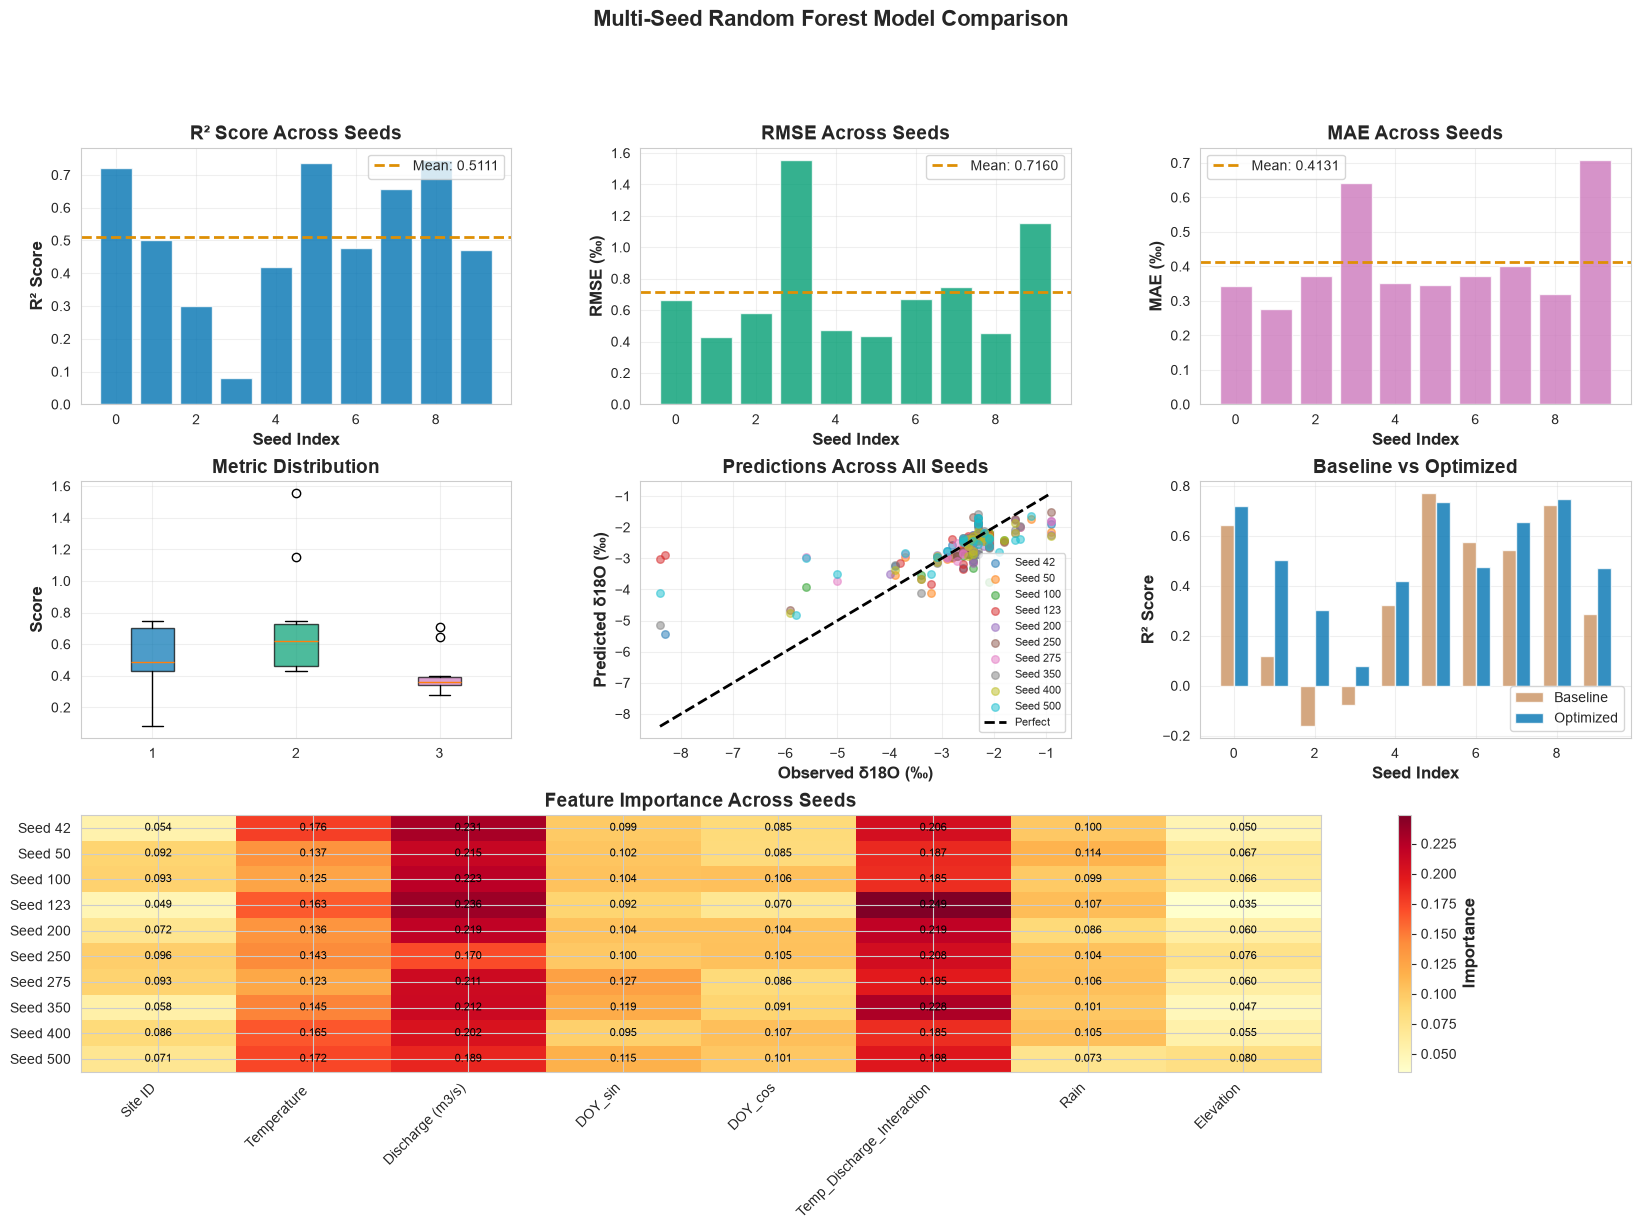

In [25]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. R² Score comparison
ax1 = fig.add_subplot(gs[0, 0])
r2_scores = [r['optimized_r2'] for r in results]
ax1.bar(range(len(SEEDS)), r2_scores, color='#0173B2', alpha=0.8)
ax1.axhline(y=np.mean(r2_scores), color='#DE8F05', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(r2_scores):.4f}')
ax1.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Score Across Seeds', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. RMSE comparison
ax2 = fig.add_subplot(gs[0, 1])
rmse_scores = [r['optimized_rmse'] for r in results]
ax2.bar(range(len(SEEDS)), rmse_scores, color='#029E73', alpha=0.8)
ax2.axhline(y=np.mean(rmse_scores), color='#DE8F05', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(rmse_scores):.4f}')
ax2.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE (‰)', fontsize=12, fontweight='bold')
ax2.set_title('RMSE Across Seeds', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. MAE comparison
ax3 = fig.add_subplot(gs[0, 2])
mae_scores = [r['optimized_mae'] for r in results]
ax3.bar(range(len(SEEDS)), mae_scores, color='#CC78BC', alpha=0.8)
ax3.axhline(y=np.mean(mae_scores), color='#DE8F05', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(mae_scores):.4f}')
ax3.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAE (‰)', fontsize=12, fontweight='bold')
ax3.set_title('MAE Across Seeds', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot
ax4 = fig.add_subplot(gs[1, 0])
bp = ax4.boxplot([r2_scores, rmse_scores, mae_scores], 
                  label=['R²', 'RMSE', 'MAE'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#0173B2', '#029E73', '#CC78BC']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('Metric Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Predicted vs Observed overlay
ax5 = fig.add_subplot(gs[1, 1])
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for i, result in enumerate(results):
    ax5.scatter(result['y_test'], result['y_pred'], 
               alpha=0.5, s=30, color=colors[i], label=f"Seed {result['seed']}")
all_y = np.concatenate([r['y_test'] for r in results])
min_val, max_val = all_y.min(), all_y.max()
ax5.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect')
ax5.set_xlabel('Observed δ18O (‰)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Predicted δ18O (‰)', fontsize=12, fontweight='bold')
ax5.set_title('Predictions Across All Seeds', fontsize=14, fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.grid(True, alpha=0.3)

# 6. Baseline vs Optimized
ax6 = fig.add_subplot(gs[1, 2])
baseline_r2 = [r['baseline_r2'] for r in results]
optimized_r2 = [r['optimized_r2'] for r in results]
x = np.arange(len(SEEDS))
width = 0.35
ax6.bar(x - width/2, baseline_r2, width, label='Baseline', color='#CA9161', alpha=0.8)
ax6.bar(x + width/2, optimized_r2, width, label='Optimized', color='#0173B2', alpha=0.8)
ax6.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax6.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax6.set_title('Baseline vs Optimized', fontsize=14, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Feature importance heatmap
ax7 = fig.add_subplot(gs[2, :])
feature_names = list(results[0]['feature_importance'].keys())
importance_matrix = np.array([[r['feature_importance'][f] for f in feature_names] 
                             for r in results])
im = ax7.imshow(importance_matrix, aspect='auto', cmap='YlOrRd')
ax7.set_yticks(range(len(SEEDS)))
ax7.set_yticklabels([f"Seed {s}" for s in SEEDS])
ax7.set_xticks(range(len(feature_names)))
ax7.set_xticklabels(feature_names, rotation=45, ha='right')
ax7.set_title('Feature Importance Across Seeds', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax7)
cbar.set_label('Importance', fontsize=12, fontweight='bold')

for i in range(len(SEEDS)):
    for j in range(len(feature_names)):
        ax7.text(j, i, f'{importance_matrix[i, j]:.3f}',
                ha="center", va="center", color="black", fontsize=8)

plt.suptitle('Multi-Seed Random Forest Model Comparison', 
            fontsize=16, fontweight='bold', y=0.995)

plt.savefig('multi_seed_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'multi_seed_comparison.png'")
plt.show()

## K-Fold CV and LOOCV Comparison Across Seeds

✓ CV comparison plot saved as 'multi_seed_cv_comparison.png'


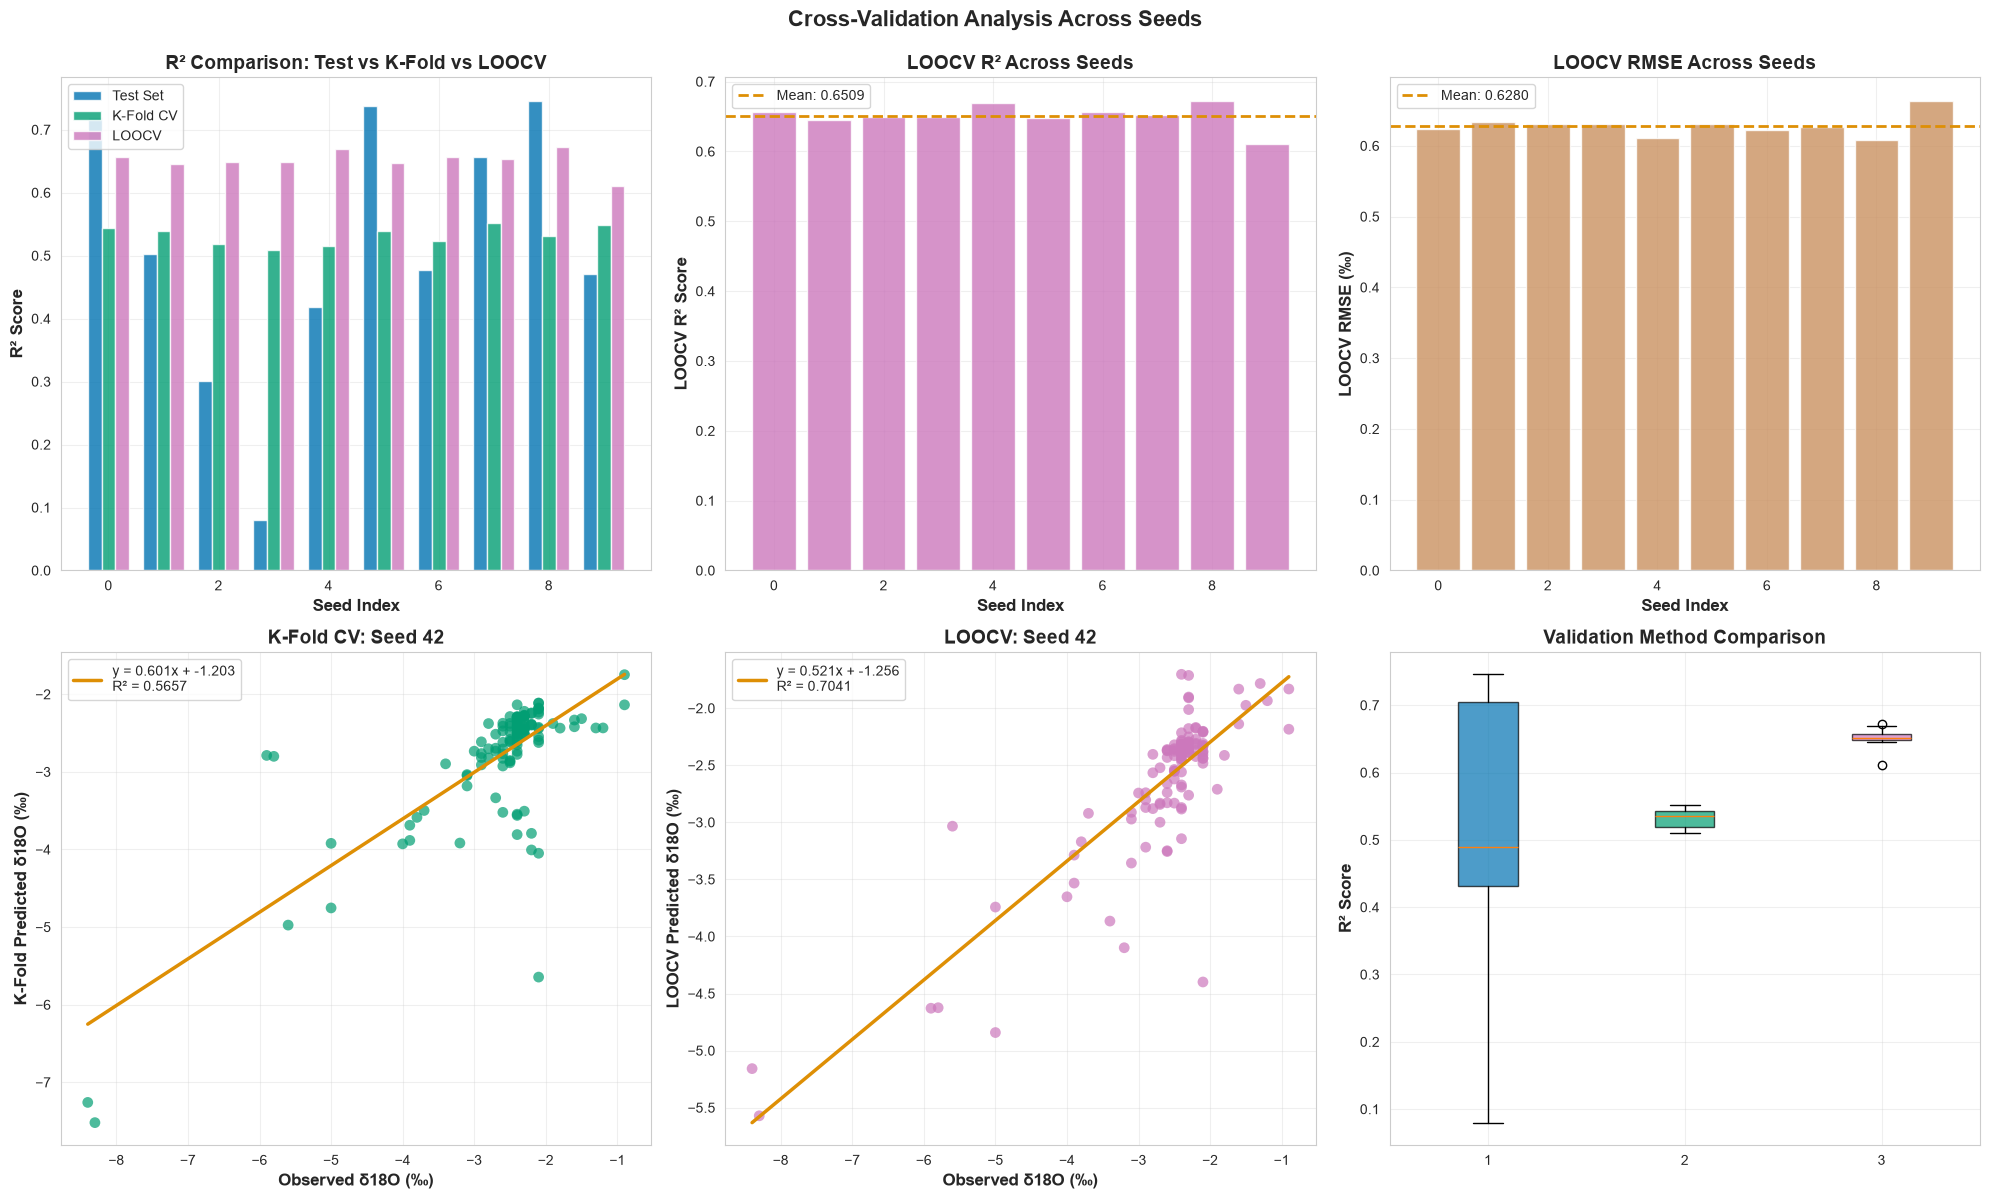

In [26]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Test Set vs K-Fold vs LOOCV R² comparison
ax = axes[0, 0]
test_r2 = [r['optimized_r2'] for r in results]
kfold_r2 = [r['kfold_r2_overall'] for r in results]
loocv_r2 = [r['loocv_r2'] for r in results]

x = np.arange(len(SEEDS))
width = 0.25
ax.bar(x - width, test_r2, width, label='Test Set', color='#0173B2', alpha=0.8)
ax.bar(x, kfold_r2, width, label='K-Fold CV', color='#029E73', alpha=0.8)
ax.bar(x + width, loocv_r2, width, label='LOOCV', color='#CC78BC', alpha=0.8)
ax.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Comparison: Test vs K-Fold vs LOOCV', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. LOOCV R² across seeds
ax = axes[0, 1]
ax.bar(range(len(SEEDS)), loocv_r2, color='#CC78BC', alpha=0.8)
ax.axhline(y=np.mean(loocv_r2), color='#DE8F05', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(loocv_r2):.4f}')
ax.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax.set_ylabel('LOOCV R² Score', fontsize=12, fontweight='bold')
ax.set_title('LOOCV R² Across Seeds', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. LOOCV RMSE across seeds
ax = axes[0, 2]
loocv_rmse = [r['loocv_rmse'] for r in results]
ax.bar(range(len(SEEDS)), loocv_rmse, color='#CA9161', alpha=0.8)
ax.axhline(y=np.mean(loocv_rmse), color='#DE8F05', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(loocv_rmse):.4f}')
ax.set_xlabel('Seed Index', fontsize=12, fontweight='bold')
ax.set_ylabel('LOOCV RMSE (‰)', fontsize=12, fontweight='bold')
ax.set_title('LOOCV RMSE Across Seeds', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. K-Fold CV Predicted vs Observed (first seed as example)
ax = axes[1, 0]
example_result = results[0]
ax.scatter(y, example_result['y_pred_kfold'], alpha=0.7, color='#029E73', s=60, edgecolors='none')
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(y, example_result['y_pred_kfold'])
line_x = np.array([y.min(), y.max()])
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5, 
        label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')
ax.set_xlabel('Observed δ18O (‰)', fontsize=12, fontweight='bold')
ax.set_ylabel('K-Fold Predicted δ18O (‰)', fontsize=12, fontweight='bold')
ax.set_title(f'K-Fold CV: Seed {example_result["seed"]}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. LOOCV Predicted vs Observed (first seed as example)
ax = axes[1, 1]
ax.scatter(example_result['y_true_loocv'], example_result['y_pred_loocv'], 
          alpha=0.7, color='#CC78BC', s=60, edgecolors='none')
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
    example_result['y_true_loocv'], example_result['y_pred_loocv'])
line_x = np.array([example_result['y_true_loocv'].min(), example_result['y_true_loocv'].max()])
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='#DE8F05', linestyle='-', lw=2.5, 
        label=f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.4f}')
ax.set_xlabel('Observed δ18O (‰)', fontsize=12, fontweight='bold')
ax.set_ylabel('LOOCV Predicted δ18O (‰)', fontsize=12, fontweight='bold')
ax.set_title(f'LOOCV: Seed {example_result["seed"]}', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Box plot comparing all validation methods
ax = axes[1, 2]
bp = ax.boxplot([test_r2, kfold_r2, loocv_r2], 
                 label=['Test Set', 'K-Fold CV', 'LOOCV'], 
                 patch_artist=True)
for patch, color in zip(bp['boxes'], ['#0173B2', '#029E73', '#CC78BC']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Validation Method Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Cross-Validation Analysis Across Seeds', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('multi_seed_cv_comparison.png', dpi=300, bbox_inches='tight')
print("✓ CV comparison plot saved as 'multi_seed_cv_comparison.png'")
plt.show()

## Save Results to JSON

In [27]:
# Prepare data for JSON
output = {
    'experiment_info': {
        'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'seeds': SEEDS,
        'num_seeds': len(SEEDS),
        'model_parameters': MODEL_PARAMS
    },
    'summary_statistics': {
        metric: {
            'mean': float(stats[metric]['mean']),
            'std': float(stats[metric]['std']),
            'min': float(stats[metric]['min']),
            'max': float(stats[metric]['max'])
        }
        for metric in stats.keys()
    },
    'individual_results': [
        {
            'seed': r['seed'],
            'baseline_r2': float(r['baseline_r2']),
            'baseline_rmse': float(r['baseline_rmse']),
            'baseline_mae': float(r['baseline_mae']),
            'optimized_r2': float(r['optimized_r2']),
            'optimized_rmse': float(r['optimized_rmse']),
            'optimized_mae': float(r['optimized_mae']),
            'kfold_r2_mean': float(r['kfold_r2_mean']),
            'kfold_r2_std': float(r['kfold_r2_std']),
            'kfold_r2_overall': float(r['kfold_r2_overall']),
            'kfold_rmse_overall': float(r['kfold_rmse_overall']),
            'kfold_mae_overall': float(r['kfold_mae_overall']),
            'loocv_r2': float(r['loocv_r2']),
            'loocv_rmse': float(r['loocv_rmse']),
            'loocv_mae': float(r['loocv_mae']),
            'feature_importance': {k: float(v) for k, v in r['feature_importance'].items()}
        }
        for r in results
    ]
}

with open('multi_seed_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("✓ Results saved to 'multi_seed_results.json'")

✓ Results saved to 'multi_seed_results.json'


## Conclusion

### Key Takeaways:
1. **Model Stability**: Check the standard deviation of metrics - lower is better
2. **Best Seed**: Use the seed with the highest R² for your final model
3. **Feature Consistency**: Features that are important across all seeds are most reliable
4. **Performance Range**: Large range indicates sensitivity to train/test split

### Next Steps:
- If standard deviation is high, consider collecting more data
- Use the best performing seed for production models
- Investigate features with consistent high importance
- Consider ensemble methods if variability is high